# Amazon Refinement Teleconnection Pathway Diagnostics

This notebook tests whether Amazon refinement changes the tropical heating pathway and downstream North Atlantic circulation.

Diagnostics:
1. Amazon DJF precipitation bias and variability
2. 200-hPa velocity potential and divergence
3. 200-hPa streamfunction wave-train regression
4. North Atlantic jet latitude
5. Storm-track EKE

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FuncFormatter

try:
    from scipy import stats
except Exception:
    stats = None

try:
    from windspharm.xarray import VectorWind
except Exception:
    VectorWind = None

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "scripts").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))
from environment import configure_proj_data
configure_proj_data(verbose=True)
import mov_config
import mov_pathway_workflow
importlib.reload(mov_config)
importlib.reload(mov_pathway_workflow)

proj_lib = "/lcrc/soft/climate/e3sm-unified/load_latest_e3sm_unified_pm-cpu/conda_envs/e3sm_unified_1.11.0_py3.10_nox/share/proj"
if os.path.isdir(proj_lib):
    os.environ.setdefault("PROJ_LIB", proj_lib)
    os.environ.setdefault("PROJ_DATA", proj_lib)

[INFO] Using PROJ data: /lcrc/soft/climate/e3sm-unified/e3smu_1_12_0/chrysalis/conda/envs/e3sm_unified_1.12.0_login/share/proj


## Configuration

In [2]:
# Analysis selection.
PERIOD = (1985, 2014)
SEASON = "DJF"
REF_CASE = "LR"

FIG_DIR = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3rrm_paper/mov_pathway_metric")
CACHE_DIR = PROJECT_ROOT / "figure_data" / "mov_pathway_metric_rrm"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DATA_ROOT = Path("/lcrc/group/e3sm2/ac.qtang/E3SMv3")
MODEL_SEARCH_SUBDIRS = [
    Path("post/atm/180x360_aave/cmip_ts/monthly"),
    Path("post/atm/180x360_aave/ts/monthly/5yr"),
]
# Experiments to compare. Edit this list for a different comparison.
PATHWAY_EXPERIMENTS = [
    mov_config.MOVExperiment(key="LR", label="LR", model_name="v3.LR.amip_0101", pcmdi_tag="v3.LR.amip_0101", data_root=MODEL_DATA_ROOT),
    mov_config.MOVExperiment(key="NARRM", label="NARRM", model_name="v3.NARRM.amip_0101", pcmdi_tag="v3.NARRM.amip_0101", data_root=MODEL_DATA_ROOT),
    mov_config.MOVExperiment(key="NARRM_r0125", label="NARRM_r0125", model_name="v3.NARRM_r0125.amip_0101", pcmdi_tag="v3.NARRM_r0125.amip_0101", data_root=MODEL_DATA_ROOT),
    mov_config.MOVExperiment(key="EARRM", label="EARRM", model_name="v3.EARRM.amip_0101", pcmdi_tag="v3.EARRM.amip_0101", data_root=MODEL_DATA_ROOT),
    mov_config.MOVExperiment(key="AMZRRM", label="AMZRRM", model_name="v3.AMZRRM.amip_0101", pcmdi_tag="v3.AMZRRM.amip_0101", data_root=MODEL_DATA_ROOT),
]
MODEL_DATASETS = {experiment.key: {"name": experiment.model_name} for experiment in PATHWAY_EXPERIMENTS}
CASE_ORDER = list(MODEL_DATASETS)
CASE_LABELS = {experiment.key: experiment.label for experiment in PATHWAY_EXPERIMENTS}

# Optional observational precipitation reference. Set path/var when you want true bias.
OBS_PR = {
    "name": "OBS",
    "path": None,
    "var": "pr",
}

AMAZON_BOUNDS = {"lat": (-15, 5), "lon": (-75, -45)}
TROPICS_BOUNDS = {"lat": (-30, 30), "lon": (-180, 180)}
NA_BOUNDS = {"lat": (20, 80), "lon": (-90, 40)}
ATLANTIC_JET_BOUNDS = {"lat": (25, 70), "lon": (-80, 20)}

# Use 850 hPa for the eddy-driven jet when available. Change to 200 for upper-level jet latitude.
JET_LEVEL_HPA = 850
WAVE_LEVEL_HPA = 200
EKE_LEVEL_HPA = 250

# Shared map-figure inputs. Individual calls still provide levels and extent.
PATHWAY_MAP_OPTIONS = dict(
    ncols=2, figsize_per_panel=(6.0, 3.2), font_size=12,
    title_font_size=14, cbar_pad=0.08, cbar_fraction=0.055,
    fig_dpi=300, sig_dot_size=2.0, sig_dot_limit=700,
)

# Daily winds are needed for synoptic storm-track EKE. Fill these if daily files are outside the monthly CMIP archive.
DAILY_WIND_FILES = {case: {"u": None, "v": None} for case in CASE_ORDER}

## Shared Helpers

In [3]:
# Thin notebook adapters around reusable workflow helpers.
def try_open_case_var(case, var_names, level_hpa=None):
    try:
        return open_case_var(case, var_names, level_hpa=level_hpa)
    except FileNotFoundError as exc:
        print(f"Skipping {case} {var_names}: {exc}")
        return None


def seasonal_year_mean(da, season=SEASON):
    da = da.sortby("time")
    if season.upper() == "DJF":
        month = da["time"].dt.month
        year = da["time"].dt.year
        winter_year = xr.where(month == 12, year + 1, year)
        sub = da.where(month.isin([12, 1, 2]), drop=True)
        sub = sub.assign_coords(season_year=("time", winter_year.where(month.isin([12, 1, 2]), drop=True).data))
        out = sub.groupby("season_year").mean("time", skipna=True)
        out = out.rename({"season_year": "year"})
        return out.sel(year=slice(PERIOD[0] + 1, PERIOD[1]))
    sub = da.where(da["time"].dt.season == season.upper(), drop=True)
    out = sub.groupby("time.year").mean("time", skipna=True)
    return out.sel(year=slice(PERIOD[0], PERIOD[1]))


def subset_box(da, bounds):
    da = normalize_coords(da)
    lat0, lat1 = bounds["lat"]
    lon0, lon1 = bounds["lon"]
    lat_slice = slice(lat0, lat1) if da.lat[0] < da.lat[-1] else slice(lat1, lat0)
    return da.sel(lat=lat_slice, lon=slice(lon0, lon1))


def area_mean(da, bounds=None):
    sub = subset_box(da, bounds) if bounds else da
    weights = np.cos(np.deg2rad(sub["lat"]))
    return sub.weighted(weights).mean(("lat", "lon"), skipna=True)


def regress_map(y, x):
    y, x = xr.align(y, x, join="inner")
    x = (x - x.mean("year")) / x.std("year")
    y_anom = y - y.mean("year")
    slope = (y_anom * x).mean("year")
    corr = xr.corr(y, x, dim="year")
    if stats is None:
        return slope, corr, xr.full_like(slope, np.nan)
    n = y["year"].size
    tval = corr * np.sqrt((n - 2) / xr.where(1 - corr**2 <= 0, np.nan, 1 - corr**2))
    pval = xr.apply_ufunc(lambda t: 2 * stats.t.sf(np.abs(t), n - 2), tval)
    return slope, corr, pval


def lon_formatter(x, pos=None):
    label = abs(int(x))
    return f"{label}W" if x < 0 else (f"{label}E" if x > 0 else "0")


def lat_formatter(y, pos=None):
    label = abs(int(y))
    return f"{label}S" if y < 0 else (f"{label}N" if y > 0 else "0")


def plot_map_grid(fields, title, cbar_label, levels, filename, extent=None, cmap="RdBu_r", pvals=None, sig_level=0.05, **figure_options):
    options = {**PATHWAY_MAP_OPTIONS, **figure_options}
    n = len(fields)
    ncols = options["ncols"]
    nrows = int(np.ceil(n / ncols))
    proj = ccrs.PlateCarree()
    panel_width, panel_height = options["figsize_per_panel"]
    fig, axes = plt.subplots(nrows, ncols, figsize=(panel_width * ncols, panel_height * nrows), subplot_kw={"projection": proj})
    axes = np.atleast_1d(axes).ravel()
    mappable = None
    for i, (label, da) in enumerate(fields):
        ax = axes[i]
        da = normalize_coords(da)
        mappable = ax.contourf(da.lon, da.lat, da, levels=levels, cmap=cmap, extend="both", transform=proj)
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.2)
        if extent:
            ax.set_extent(extent, crs=proj)
        ax.set_title(f"({chr(97 + i)}) {label}", loc="left", fontsize=options["font_size"])
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.gridlines(draw_labels=False, linewidth=0.25, color="0.7", alpha=0.6)
        if pvals is not None and pvals[i] is not None:
            pv = normalize_coords(pvals[i]).interp(lat=da.lat, lon=da.lon)
            mask = pv < sig_level
            yy, xx = np.where(mask.values)
            step = max(1, int(np.sqrt(max(1, yy.size) / options["sig_dot_limit"])))
            ax.scatter(da.lon.values[xx[::step]], da.lat.values[yy[::step]], s=options["sig_dot_size"], c="k", alpha=0.5, transform=proj)
    for ax in axes[n:]:
        ax.remove()
    fig.suptitle(title, fontsize=options["title_font_size"], y=0.995)
    cbar = fig.colorbar(mappable, ax=axes[:n], orientation="horizontal", pad=options["cbar_pad"], fraction=options["cbar_fraction"])
    cbar.set_label(cbar_label)
    out = FIG_DIR / filename
    fig.savefig(out, dpi=options["fig_dpi"], bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

# Shared implementations; wrappers retain the concise downstream API.
normalize_coords = mov_pathway_workflow.normalize_coords
select_level = mov_pathway_workflow.select_level
standardize_units = mov_pathway_workflow.standardize_units
subset_box = mov_pathway_workflow.subset_box
area_mean = mov_pathway_workflow.area_mean
highpass_transient = mov_pathway_workflow.highpass_transient
def case_monthly_dirs(case):
    return mov_pathway_workflow.case_monthly_dirs(case, datasets=MODEL_DATASETS, data_root=MODEL_DATA_ROOT, search_subdirs=MODEL_SEARCH_SUBDIRS)
def find_case_files(case, var_names):
    return mov_pathway_workflow.find_case_files(case, var_names, datasets=MODEL_DATASETS, data_root=MODEL_DATA_ROOT, search_subdirs=MODEL_SEARCH_SUBDIRS)
def open_case_var(case, var_names, level_hpa=None):
    return mov_pathway_workflow.open_case_var(case, var_names, datasets=MODEL_DATASETS, data_root=MODEL_DATA_ROOT, search_subdirs=MODEL_SEARCH_SUBDIRS, period=PERIOD, level_hpa=level_hpa)
def seasonal_year_mean(da, season=SEASON):
    return mov_pathway_workflow.seasonal_year_mean(da, period=PERIOD, season=season)
def regress_map(y, x):
    return mov_pathway_workflow.regress_map(y, x, stats_module=stats)


## File Inventory

In [4]:
inventory = {}
for case in CASE_ORDER:
    prefixes = set()
    for base in case_monthly_dirs(case):
        if base.exists():
            prefixes.update(path.name.split("_")[0] for path in base.glob("*.nc"))
    inventory[case] = sorted(prefixes)

inventory_df = pd.DataFrame({case: pd.Series(vals) for case, vals in inventory.items()})
display(inventory_df)

required = {
    "precipitation": ["pr", "PRECT"],
    "200-hPa winds": ["U", "V", "ua", "va", "U200", "V200"],
    "jet winds": ["U", "ua", "U850"],
}
for label, aliases in required.items():
    missing = [case for case, vars_found in inventory.items() if not any(alias in vars_found for alias in aliases)]
    if missing:
        print(f"Missing {label} aliases {aliases} for: {missing}")
    else:
        print(f"Found {label} aliases for all cases.")

,LR,NARRM,NARRM_r0125,EARRM,AMZRRM
0,AODABS,AODABS,AODABS,AODABS,AODABS
1,AODDUST,AODDUST,AODDUST,AODDUST,AODDUST
2,AODVIS,AODVIS,AODVIS,AODVIS,AODVIS
3,CLDHGH,CLDHGH,CLDHGH,CLDHGH,CLDHGH
4,CLDICE,CLDICE,CLDICE,CLDICE,CLDICE
...,...,...,...,...,...
79,tasmax,tasmax,tasmax,tasmax,tasmax
80,tasmin,tasmin,tasmin,tasmin,tasmin
81,tauu,tauu,tauu,tauu,tauu
82,tauv,tauv,tauv,tauv,tauv


Found precipitation aliases for all cases.
Found 200-hPa winds aliases for all cases.
Found jet winds aliases for all cases.


## Load Core Monthly Fields

In [5]:
pr = {}
u200 = {}
v200 = {}
ujet = {}

for case in CASE_ORDER:
    print(f"Loading {case}")
    pr[case] = standardize_units(open_case_var(case, ["pr", "PRECT"]), "precip")
    u200[case] = try_open_case_var(case, ["ua", "U", "U200"], level_hpa=WAVE_LEVEL_HPA)
    v200[case] = try_open_case_var(case, ["va", "V", "V200"], level_hpa=WAVE_LEVEL_HPA)
    ujet[case] = try_open_case_var(case, ["ua", "U", "U850"], level_hpa=JET_LEVEL_HPA)

obs_pr = None
if OBS_PR["path"]:
    obs_ds = normalize_coords(xr.open_mfdataset(OBS_PR["path"], combine="by_coords", use_cftime=True))
    obs_pr = standardize_units(obs_ds[OBS_PR["var"]], "precip")

Loading LR
Skipping LR ['va', 'V', 'V200']: No files found for LR with variables ['va', 'V', 'V200']. Searched: /lcrc/group/e3sm2/ac.qtang/E3SMv3/v3.LR.amip_0101/post/atm/180x360_aave/cmip_ts/monthly, /lcrc/group/e3sm2/ac.qtang/E3SMv3/v3.LR.amip_0101/post/atm/180x360_aave/ts/monthly/5yr
Loading NARRM
Skipping NARRM ['va', 'V', 'V200']: No files found for NARRM with variables ['va', 'V', 'V200']. Searched: /lcrc/group/e3sm2/ac.qtang/E3SMv3/v3.NARRM.amip_0101/post/atm/180x360_aave/cmip_ts/monthly, /lcrc/group/e3sm2/ac.qtang/E3SMv3/v3.NARRM.amip_0101/post/atm/180x360_aave/ts/monthly/5yr
Loading NARRM_r0125
Skipping NARRM_r0125 ['va', 'V', 'V200']: No files found for NARRM_r0125 with variables ['va', 'V', 'V200']. Searched: /lcrc/group/e3sm2/ac.qtang/E3SMv3/v3.NARRM_r0125.amip_0101/post/atm/180x360_aave/cmip_ts/monthly, /lcrc/group/e3sm2/ac.qtang/E3SMv3/v3.NARRM_r0125.amip_0101/post/atm/180x360_aave/ts/monthly/5yr
Loading EARRM
Skipping EARRM ['va', 'V', 'V200']: No files found for EARRM w

## 1. Amazon DJF Precipitation Bias and Variability

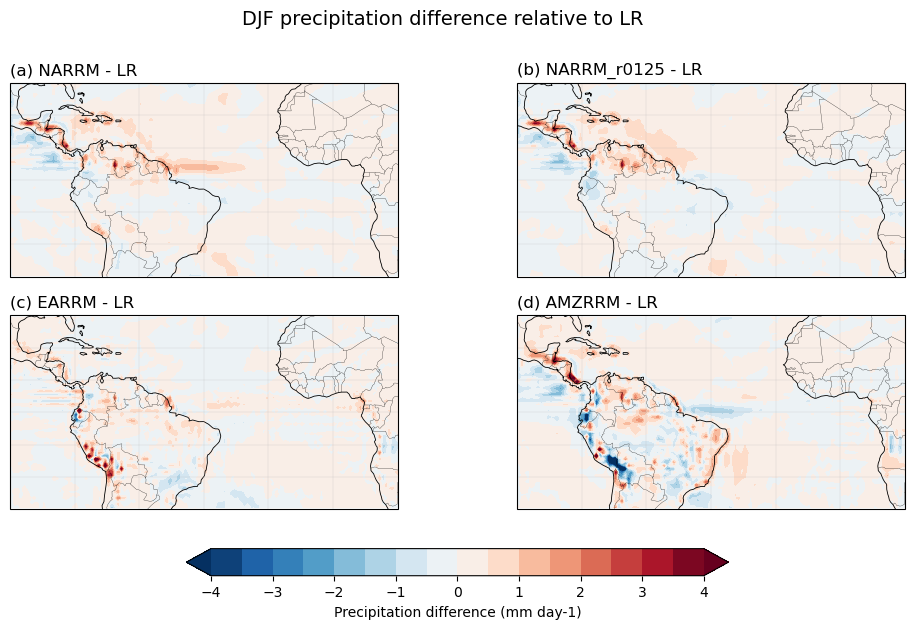

Saved figures/amazon_teleconnection_pathway/amazon_djf_precip_difference.png


,Amazon mean (mm day-1),Amazon variability (std)
LR,8.394899,0.554787
NARRM,8.511519,0.456915
NARRM_r0125,8.410962,0.494178
EARRM,8.530478,0.507992
AMZRRM,8.252182,0.424706


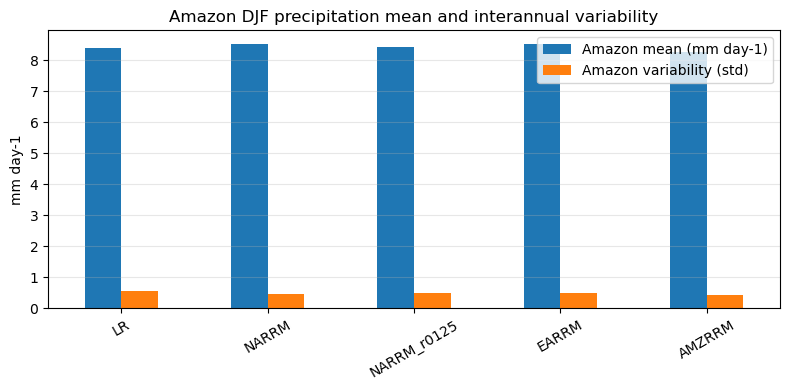

In [6]:
pr_djf = {case: seasonal_year_mean(da) for case, da in pr.items()}
pr_clim = {case: da.mean("year") for case, da in pr_djf.items()}
amazon_pr = {case: area_mean(da, AMAZON_BOUNDS) for case, da in pr_djf.items()}

if obs_pr is not None:
    obs_pr_djf = seasonal_year_mean(obs_pr)
    pr_ref_name = OBS_PR["name"]
    pr_ref_clim = obs_pr_djf.mean("year")
else:
    pr_ref_name = REF_CASE
    pr_ref_clim = pr_clim[REF_CASE]

pr_diff_fields = []
for case in CASE_ORDER:
    if obs_pr is None and case == REF_CASE:
        continue  # Do not plot the identically zero reference-minus-reference field.
    diff = pr_clim[case] - pr_ref_clim.interp(lat=pr_clim[case].lat, lon=pr_clim[case].lon)
    pr_diff_fields.append((f"{case} - {pr_ref_name}", subset_box(diff, TROPICS_BOUNDS)))

plot_map_grid(
    pr_diff_fields,
    f"DJF precipitation difference relative to {pr_ref_name}",
    "Precipitation difference (mm day-1)",
    np.linspace(-4, 4, 17),
    "amazon_djf_precip_difference.png",
    extent=[-100, 20, -30, 30],
)

pr_metrics = pd.DataFrame({
    "Amazon mean (mm day-1)": {case: float(ts.mean("year")) for case, ts in amazon_pr.items()},
    "Amazon variability (std)": {case: float(ts.std("year")) for case, ts in amazon_pr.items()},
})
display(pr_metrics)

ax = pr_metrics.plot(kind="bar", figsize=(8, 4), rot=30)
ax.set_ylabel("mm day-1")
ax.set_title("Amazon DJF precipitation mean and interannual variability")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "amazon_djf_precip_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. 200-hPa Velocity Potential and Divergence

In [7]:
def compute_divergence_chi(u, v):
    u, v = xr.align(normalize_coords(u), normalize_coords(v), join="inner")
    if VectorWind is None:
        raise ImportError("windspharm is required for spherical divergence and velocity potential.")
    wind = VectorWind(u, v)
    div = wind.divergence()
    chi = wind.velocitypotential()
    return div, chi


div200 = {}
chi200 = {}
if VectorWind is None:
    print("Skipping divergence/velocity potential: windspharm is not installed in this kernel.")
else:
    for case in CASE_ORDER:
        if u200.get(case) is None or v200.get(case) is None:
            print(f"Skipping {case}: both U and V are required for divergence/velocity potential.")
            continue
        div, chi = compute_divergence_chi(u200[case], v200[case])
        div200[case] = seasonal_year_mean(div).mean("year")
        chi200[case] = seasonal_year_mean(chi).mean("year")

div_fields = []
chi_fields = []
for case in CASE_ORDER:
    if case == REF_CASE:
        continue  # Do not plot LR - LR.
    if case not in div200 or REF_CASE not in div200:
        continue
    div_fields.append((f"{case} - {REF_CASE}", subset_box((div200[case] - div200[REF_CASE]).interp(lat=div200[case].lat, lon=div200[case].lon), TROPICS_BOUNDS)))
    chi_fields.append((f"{case} - {REF_CASE}", subset_box((chi200[case] - chi200[REF_CASE]).interp(lat=chi200[case].lat, lon=chi200[case].lon), TROPICS_BOUNDS)))

if div_fields:
    plot_map_grid(div_fields, "DJF 200-hPa divergence difference", "Divergence (s-1)", np.linspace(-4e-6, 4e-6, 17), "tropical_div200_difference.png", extent=[-180, 180, -30, 30])
    plot_map_grid(chi_fields, "DJF 200-hPa velocity potential difference", "Velocity potential (m2 s-1)", np.linspace(-4e6, 4e6, 17), "tropical_chi200_difference.png", extent=[-180, 180, -30, 30])

Skipping LR: both U and V are required for divergence/velocity potential.
Skipping NARRM: both U and V are required for divergence/velocity potential.
Skipping NARRM_r0125: both U and V are required for divergence/velocity potential.
Skipping EARRM: both U and V are required for divergence/velocity potential.
Skipping AMZRRM: both U and V are required for divergence/velocity potential.


## 3. 200-hPa Streamfunction Wave-Train Regression

In [8]:
def compute_streamfunction(u, v):
    if VectorWind is None:
        raise ImportError("windspharm is required for 200-hPa streamfunction.")
    u, v = xr.align(normalize_coords(u), normalize_coords(v), join="inner")
    return VectorWind(u, v).streamfunction()


psi_reg_fields = []
psi_pvals = []
if VectorWind is None:
    print("Skipping streamfunction regression: windspharm is not installed in this kernel.")

for case in CASE_ORDER if VectorWind is not None else []:
    if u200.get(case) is None or v200.get(case) is None:
        print(f"Skipping {case}: both U and V are required for streamfunction.")
        continue
    psi = seasonal_year_mean(compute_streamfunction(u200[case], v200[case]))
    amazon_index = amazon_pr[case]
    slope, corr, pval = regress_map(psi, amazon_index)
    psi_reg_fields.append((case, subset_box(slope, {"lat": (-20, 80), "lon": (-120, 60)})))
    psi_pvals.append(subset_box(pval, {"lat": (-20, 80), "lon": (-120, 60)}))

if psi_reg_fields:
    plot_map_grid(
        psi_reg_fields,
        "200-hPa streamfunction regression onto standardized Amazon DJF precipitation",
        "Streamfunction regression (m2 s-1 per std)",
        np.linspace(-8e6, 8e6, 17),
        "psi200_regression_amazon_precip.png",
        extent=[-120, 60, -20, 80],
        pvals=psi_pvals,
        sig_level=0.10,
    )

Skipping LR: both U and V are required for streamfunction.
Skipping NARRM: both U and V are required for streamfunction.
Skipping NARRM_r0125: both U and V are required for streamfunction.
Skipping EARRM: both U and V are required for streamfunction.
Skipping AMZRRM: both U and V are required for streamfunction.


## 4. North Atlantic Jet Latitude

,mean,std,min,max
LR,43.258621,4.997536,35.5,57.5
NARRM,44.086207,4.873524,36.5,53.5
NARRM_r0125,43.500000,5.700877,36.5,56.5
EARRM,42.982759,4.041046,36.5,52.5
AMZRRM,43.706897,4.353810,37.5,50.5


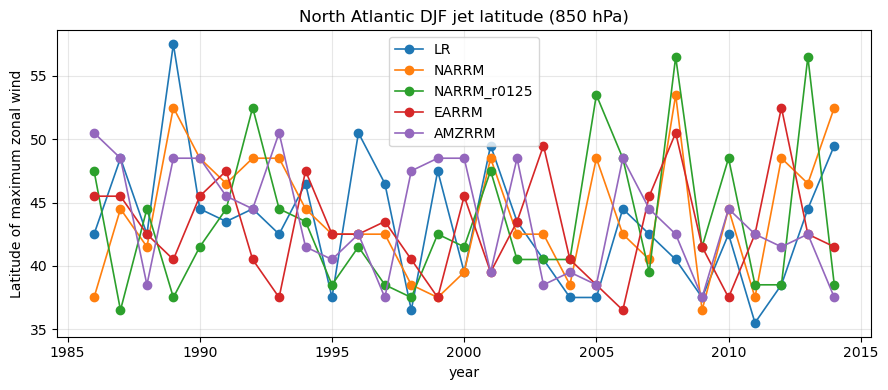

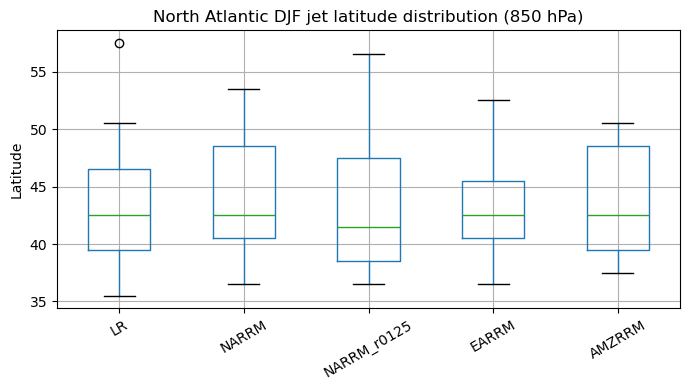

In [9]:
jet_latitude = {}
for case, u in ujet.items():
    if u is None:
        print(f"Skipping {case}: no zonal wind field available for jet latitude.")
        continue
    u_djf = seasonal_year_mean(u)
    u_atl = subset_box(u_djf, ATLANTIC_JET_BOUNDS).mean("lon", skipna=True)
    jet_latitude[case] = u_atl["lat"].isel(lat=u_atl.argmax("lat"))

jet_df = pd.DataFrame({case: jet_latitude[case].to_series() for case in CASE_ORDER if case in jet_latitude})
display(jet_df.describe().T[["mean", "std", "min", "max"]])

fig, ax = plt.subplots(figsize=(9, 4))
jet_df.plot(ax=ax, marker="o", linewidth=1.2)
ax.set_ylabel("Latitude of maximum zonal wind")
ax.set_title(f"North Atlantic DJF jet latitude ({JET_LEVEL_HPA} hPa)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "north_atlantic_jet_latitude_timeseries.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
jet_df.boxplot(ax=ax)
ax.set_ylabel("Latitude")
ax.set_title(f"North Atlantic DJF jet latitude distribution ({JET_LEVEL_HPA} hPa)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "north_atlantic_jet_latitude_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Storm-Track EKE

Synoptic storm-track EKE requires daily or higher-frequency winds. Monthly means cannot recover 2-8 day transient eddies, so this section is active only after daily U/V paths are provided in `DAILY_WIND_FILES`.

In [10]:
def open_daily_wind(path, var_names, level_hpa=EKE_LEVEL_HPA):
    ds = normalize_coords(xr.open_mfdataset(path, combine="by_coords", use_cftime=True))
    var = next((v for v in var_names if v in ds.data_vars), list(ds.data_vars)[0])
    da = select_level(normalize_coords(ds[var]), level_hpa)
    return da.sel(time=slice(f"{PERIOD[0]}-01-01", f"{PERIOD[1]}-12-31"))


def highpass_transient(da, window=8):
    smooth = da.rolling(time=window, center=True, min_periods=window // 2).mean()
    return da - smooth


eke_fields = []
eke_metrics = {}
for case, files in DAILY_WIND_FILES.items():
    if not files["u"] or not files["v"]:
        print(f"Skipping {case}: provide daily u/v files for storm-track EKE.")
        continue
    u_day = open_daily_wind(files["u"], ["ua", "U"], EKE_LEVEL_HPA)
    v_day = open_daily_wind(files["v"], ["va", "V"], EKE_LEVEL_HPA)
    up = highpass_transient(u_day)
    vp = highpass_transient(v_day)
    eke = 0.5 * (up**2 + vp**2)
    eke_djf = seasonal_year_mean(eke).mean("year")
    eke_fields.append((case, subset_box(eke_djf, NA_BOUNDS)))
    eke_metrics[case] = float(area_mean(eke_djf, NA_BOUNDS))

if eke_fields:
    plot_map_grid(eke_fields, f"DJF storm-track EKE ({EKE_LEVEL_HPA} hPa)", "EKE (m2 s-2)", np.linspace(0, 250, 11), "storm_track_eke.png", extent=[-90, 40, 20, 80], cmap="YlOrRd")
    display(pd.Series(eke_metrics, name="North Atlantic EKE").to_frame())

Skipping LR: provide daily u/v files for storm-track EKE.
Skipping NARRM: provide daily u/v files for storm-track EKE.
Skipping NARRM_r0125: provide daily u/v files for storm-track EKE.
Skipping EARRM: provide daily u/v files for storm-track EKE.
Skipping AMZRRM: provide daily u/v files for storm-track EKE.


## Pathway Summary

In [11]:
summary = pd.DataFrame(index=CASE_ORDER)
summary["Amazon precip mean"] = [float(amazon_pr[c].mean("year")) for c in CASE_ORDER]
summary["Amazon precip std"] = [float(amazon_pr[c].std("year")) for c in CASE_ORDER]
summary[f"Jet latitude mean ({JET_LEVEL_HPA} hPa)"] = [float(jet_latitude[c].mean("year")) if c in jet_latitude else np.nan for c in CASE_ORDER]
summary[f"Jet latitude std ({JET_LEVEL_HPA} hPa)"] = [float(jet_latitude[c].std("year")) if c in jet_latitude else np.nan for c in CASE_ORDER]
if "eke_metrics" in globals() and eke_metrics:
    summary[f"NA storm-track EKE ({EKE_LEVEL_HPA} hPa)"] = pd.Series(eke_metrics)
display(summary)

display(summary.subtract(summary.loc[REF_CASE], axis="columns").rename_axis(f"Difference from {REF_CASE}"))

,Amazon precip mean,Amazon precip std,Jet latitude mean (850 hPa),Jet latitude std (850 hPa)
LR,8.394899,0.554787,43.258621,4.910616
NARRM,8.511519,0.456915,44.086207,4.788760
NARRM_r0125,8.410962,0.494178,43.500000,5.601724
EARRM,8.530478,0.507992,42.982759,3.970761
AMZRRM,8.252182,0.424706,43.706897,4.278086


,Amazon precip mean,Amazon precip std,Jet latitude mean (850 hPa),Jet latitude std (850 hPa)
Difference from LR,,,,
LR,0.000000,0.000000,0.000000,0.000000
NARRM,0.116619,-0.097872,0.827586,-0.121856
NARRM_r0125,0.016062,-0.060609,0.241379,0.691108
EARRM,0.135579,-0.046795,-0.275862,-0.939855
AMZRRM,-0.142717,-0.130080,0.448276,-0.632530
